# BMW car sales project in Python

In [1]:
# Importing essential libraries
import pandas as pd        # For data handling and analysis
import numpy as np         # For numerical computations
import matplotlib.pyplot as plt  # For plotting and visualization
import seaborn as sns      # For advanced visualizations

# Machine Learning libraries from scikit-learn
from sklearn.model_selection import train_test_split   # For splitting dataset
from sklearn.preprocessing import StandardScaler, LabelEncoder  # For scaling and encoding
from sklearn.impute import SimpleImputer  # For handling missing values
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score


from sklearn.linear_model import LogisticRegression  # Regression models
from sklearn.tree import DecisionTreeClassifier        # Decision Tree
from sklearn.ensemble import RandomForestClassifier  # Ensemble models
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors




In [2]:
# Load the dataset
df = pd.read_csv("bmw_cars_market_dataset_synthetic.csv")

# Display first 5 rows
print("Dataset Head:")
print(df.head())


Dataset Head:
   car_id     model  year  engine_size  horsepower fuel_type transmission  \
0       1        X5  2016          4.0         272    diesel    automatic   
1       2  1 Series  2022          2.6         218    petrol    automatic   
2       3        X1  2012          2.2         240    petrol    automatic   
3       4        X5  2022          3.8         316    diesel          NaN   
4       5  7 Series  2023          3.1         294    petrol    automatic   

  drivetrain  mileage_km  fuel_consumption_l_per_100km  price_usd  \
0        AWD       74655                           8.9      66756   
1        FWD       23469                           8.4      26867   
2        FWD      123273                           7.8      31313   
3        AWD       33064                           9.4      81594   
4        RWD       23926                           NaN     104105   

   co2_emissions_g_km  doors  seats  body_type  color  owner_count  \
0               196.0      5      5   

In [3]:

# Dataset info
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  int64  
 1   model                         10000 non-null  str    
 2   year                          10000 non-null  int64  
 3   engine_size                   9757 non-null   float64
 4   horsepower                    10000 non-null  int64  
 5   fuel_type                     10000 non-null  str    
 6   transmission                  9785 non-null   str    
 7   drivetrain                    10000 non-null  str    
 8   mileage_km                    10000 non-null  int64  
 9   fuel_consumption_l_per_100km  9754 non-null   float64
 10  price_usd                     10000 non-null  int64  
 11  co2_emissions_g_km            9775 non-null   float64
 12  doors                         10000 non-null  int64  
 13

In [4]:

# Statistical summary
print("\nDataset Description:")
print(df.describe(include="all"))



Dataset Description:
             car_id     model          year  engine_size    horsepower  \
count   10000.00000     10000  10000.000000  9757.000000  10000.000000   
unique          NaN        12           NaN          NaN           NaN   
top             NaN  3 Series           NaN          NaN           NaN   
freq            NaN      1626           NaN          NaN           NaN   
mean     5000.50000       NaN   2016.381700     2.484555    269.948600   
std      2886.89568       NaN      5.442478     1.201003     80.687398   
min         1.00000       NaN   2005.000000     0.000000    120.000000   
25%      2500.75000       NaN   2012.000000     2.000000    211.000000   
50%      5000.50000       NaN   2017.000000     2.600000    260.000000   
75%      7500.25000       NaN   2021.000000     3.300000    317.000000   
max     10000.00000       NaN   2024.000000     5.000000    700.000000   

       fuel_type transmission drivetrain     mileage_km  \
count      10000         9785 

Missing Values per Column:
car_id                            0
model                             0
year                              0
engine_size                     243
horsepower                        0
fuel_type                         0
transmission                    215
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    246
price_usd                         0
co2_emissions_g_km              225
doors                             0
seats                             0
body_type                         0
color                           239
owner_count                     255
accident_history                254
service_history                 231
country_sold                      0
dtype: int64


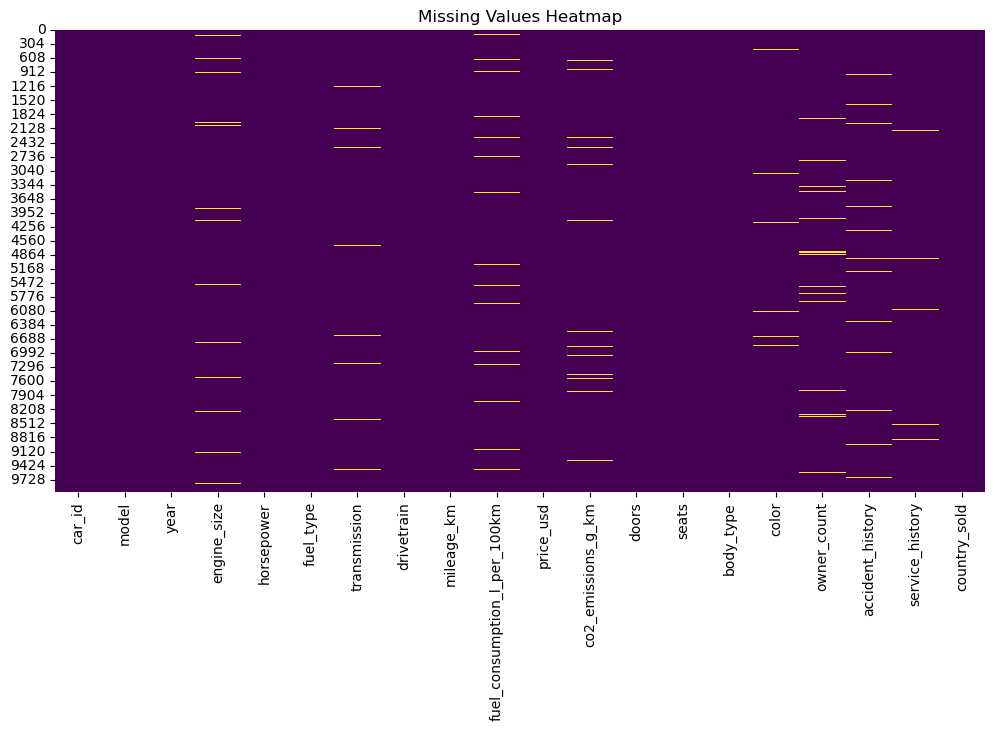

In [5]:
# Check missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Visualize missing values with a heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


            car_id          year  engine_size    horsepower     mileage_km  \
count  10000.00000  10000.000000  9757.000000  10000.000000   10000.000000   
mean    5000.50000   2016.381700     2.484555    269.948600  112364.794000   
std     2886.89568      5.442478     1.201003     80.687398   86335.775989   
min        1.00000   2005.000000     0.000000    120.000000       0.000000   
25%     2500.75000   2012.000000     2.000000    211.000000   39924.000000   
50%     5000.50000   2017.000000     2.600000    260.000000   94483.000000   
75%     7500.25000   2021.000000     3.300000    317.000000  171752.750000   
max    10000.00000   2024.000000     5.000000    700.000000  300000.000000   

       fuel_consumption_l_per_100km      price_usd  co2_emissions_g_km  \
count                   9754.000000   10000.000000         9775.000000   
mean                       6.568987   50861.398800          144.105678   
std                        3.021995   31131.966363           67.019864   
m

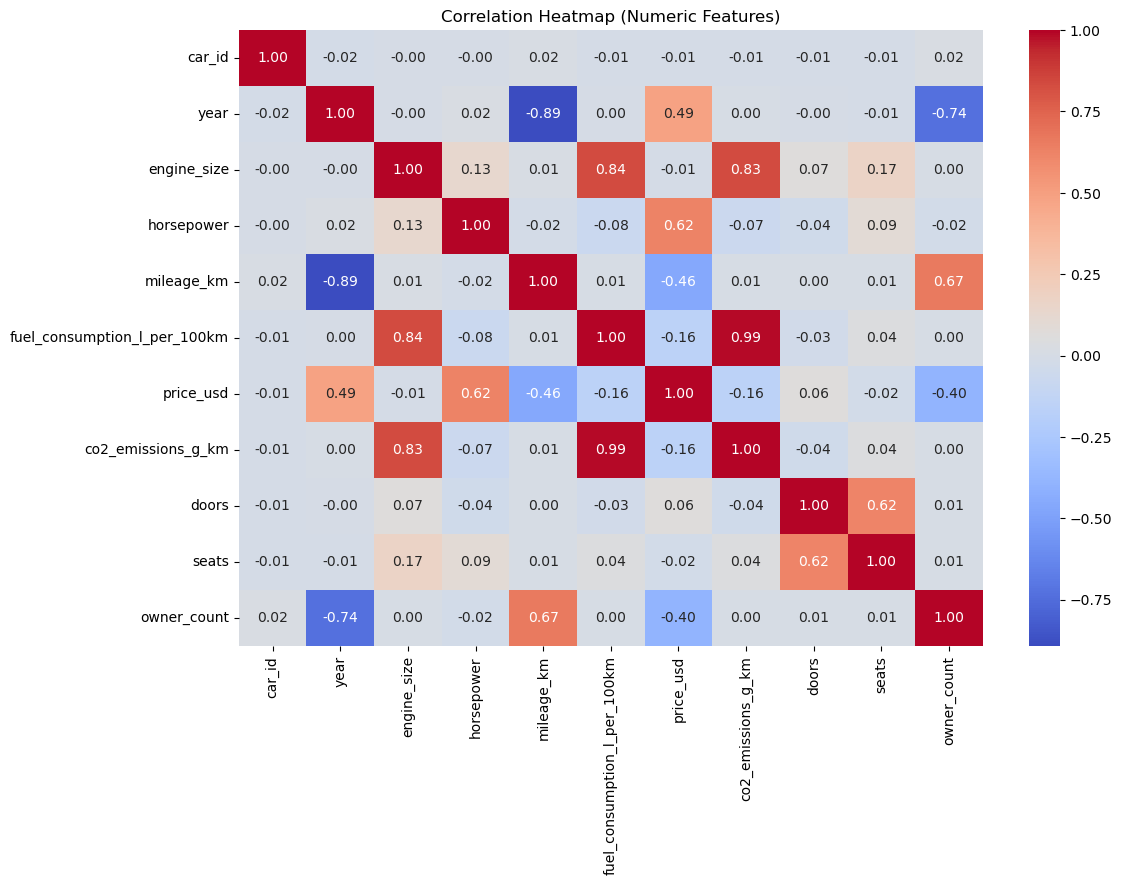

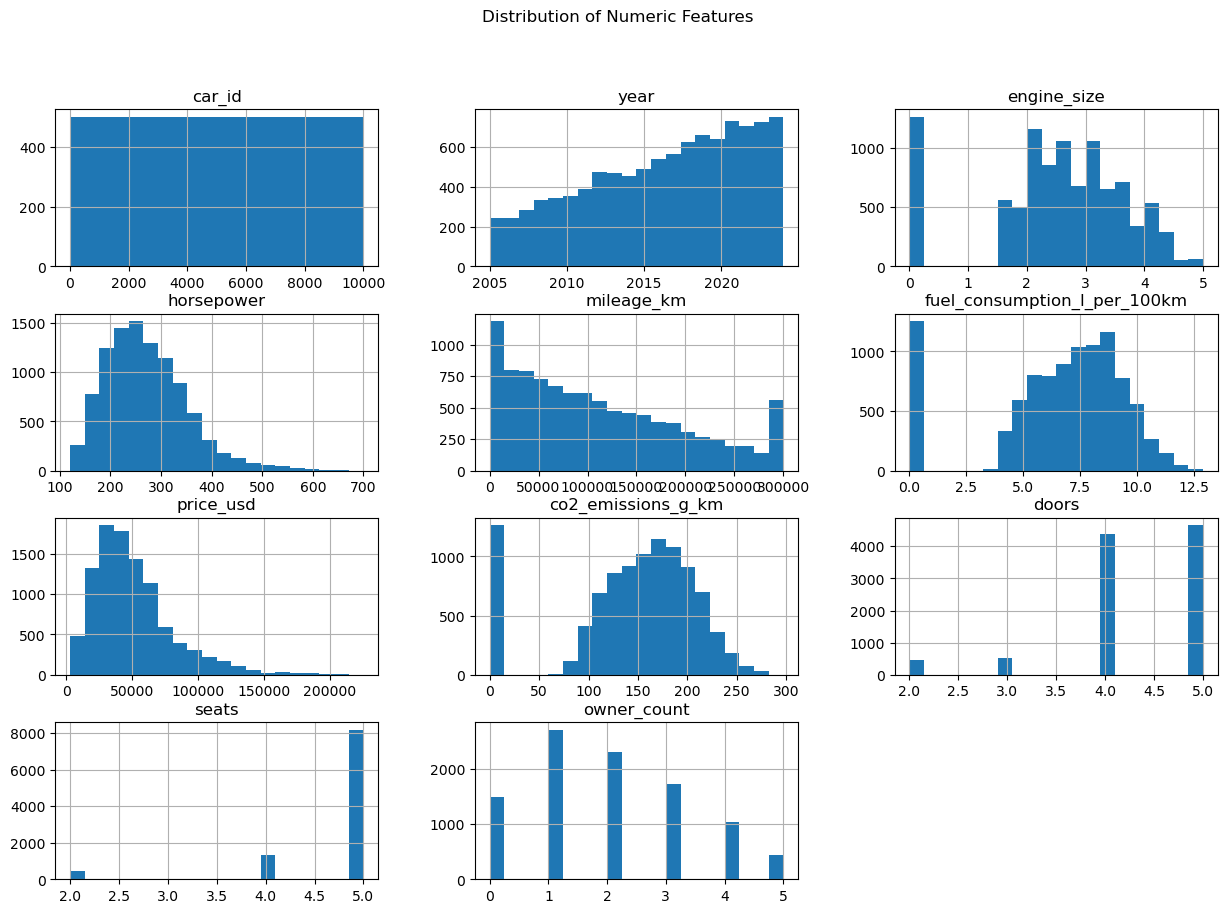

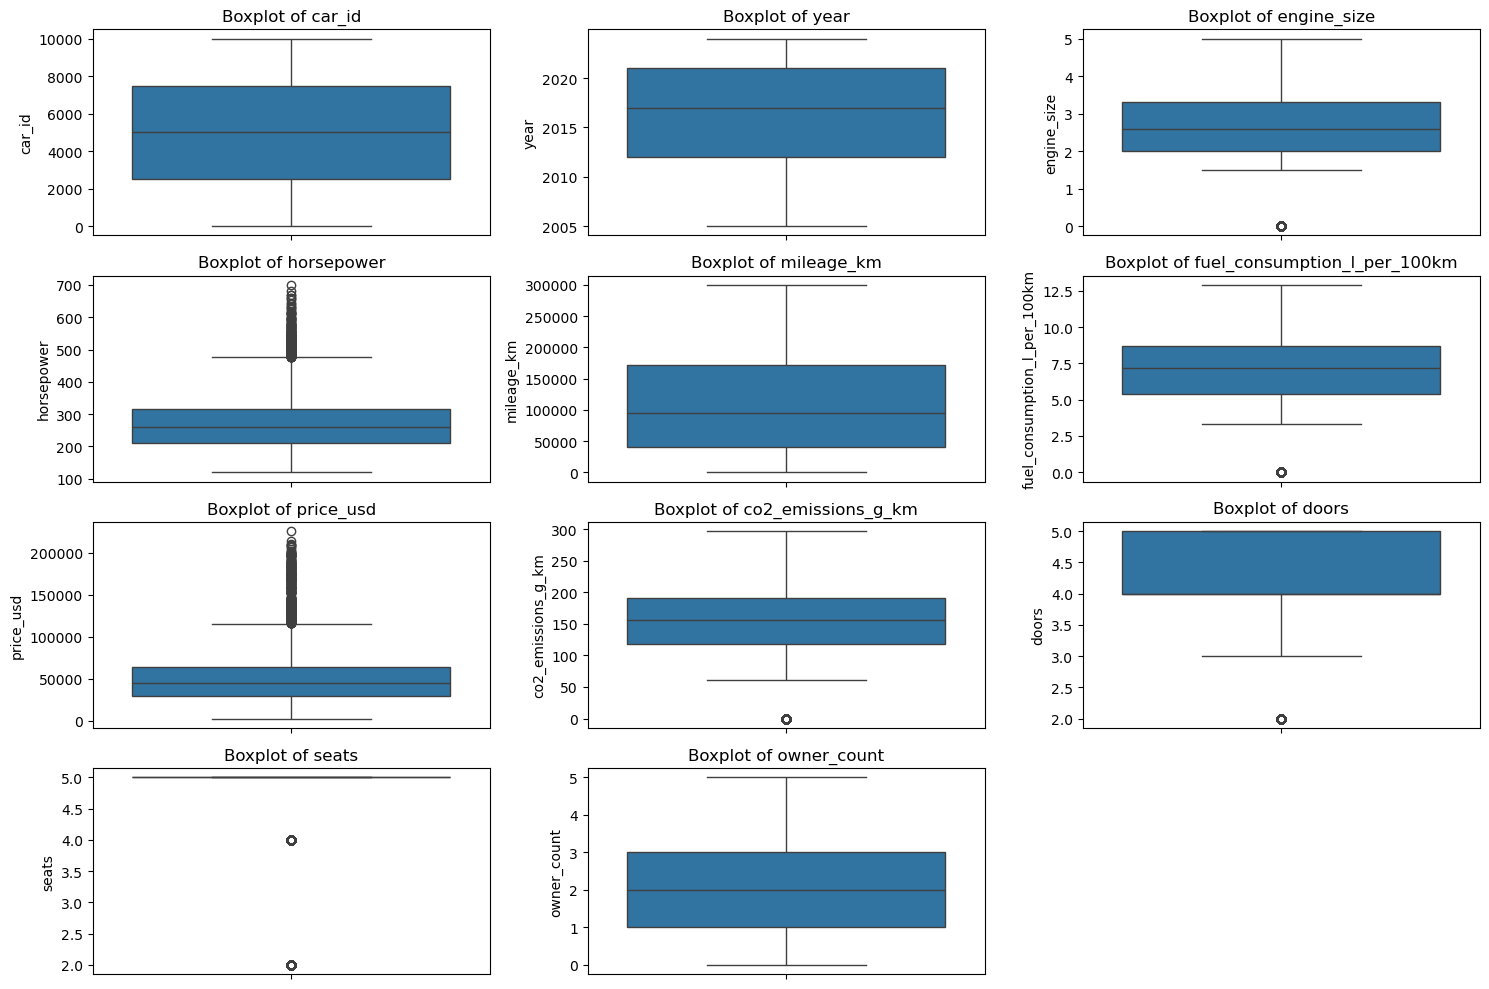

In [6]:
# Select numeric columns
num_cols = df.select_dtypes(include=np.number).columns

# Summary statistics
print(df[num_cols].describe())

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


# Histograms for numeric columns
df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.show()

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [7]:
# Data Cleaning

# Remove duplicate rows
df = df.drop_duplicates()

# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Label encoding categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# Handle missing values
numeric_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy="mean")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Check dataset info after cleaning
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  float64
 1   model                         10000 non-null  float64
 2   year                          10000 non-null  float64
 3   engine_size                   10000 non-null  float64
 4   horsepower                    10000 non-null  float64
 5   fuel_type                     10000 non-null  float64
 6   transmission                  10000 non-null  float64
 7   drivetrain                    10000 non-null  float64
 8   mileage_km                    10000 non-null  float64
 9   fuel_consumption_l_per_100km  10000 non-null  float64
 10  price_usd                     10000 non-null  float64
 11  co2_emissions_g_km            10000 non-null  float64
 12  doors                         10000 non-null  float64
 13

C:\Users\dd\AppData\Local\Temp\ipykernel_20204\2124273949.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [14]:
# save the cleaned dataset to a new CSV file
df.to_csv("bmw_cars_market_dataset_cleaned.csv", index=False)

In [8]:
# feature and target selection

# assuming last column is the target variable
X = df.iloc[:, :-1]  # Features (all columns except the last)
y=df.iloc[:, -1]   # Target variable (last column)


In [9]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# feauture scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
# Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC()
}


In [11]:
# train and evaluate each model

results = {}
for name, model in models.items():
    
    print("*" * 50)
    print(f"Training and evaluating {name}...")
    print("*" * 50)
    #
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Confusion Matrix": conf_matrix,
        "Classification Report": class_report
    }
    
    # Print results
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    print("Classification Report:")
    print(class_report)
    

**************************************************
Training and evaluating Logistic Regression...
**************************************************

Logistic Regression Results:
Accuracy: 0.1300
Confusion Matrix:
[[19 29 32 35 67 38 31 11]
 [29 30 38 25 40 26 34  3]
 [16 26 41 33 65 20 33  6]
 [27 33 36 29 68 29 22  5]
 [28 30 28 24 61 45 35  9]
 [28 23 40 32 64 49 22  8]
 [26 33 31 34 64 30 30  9]
 [19 29 30 31 62 37 32  1]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.10      0.07      0.08       262
         1.0       0.13      0.13      0.13       225
         2.0       0.15      0.17      0.16       240
         3.0       0.12      0.12      0.12       249
         4.0       0.12      0.23      0.16       260
         5.0       0.18      0.18      0.18       266
         6.0       0.13      0.12      0.12       257
         7.0       0.02      0.00      0.01       241

    accuracy                           0.13      2000
   m


Model Comparison:
                        Accuracy
Logistic Regression       0.1300
Random Forest             0.1430
Support Vector Machine    0.1315


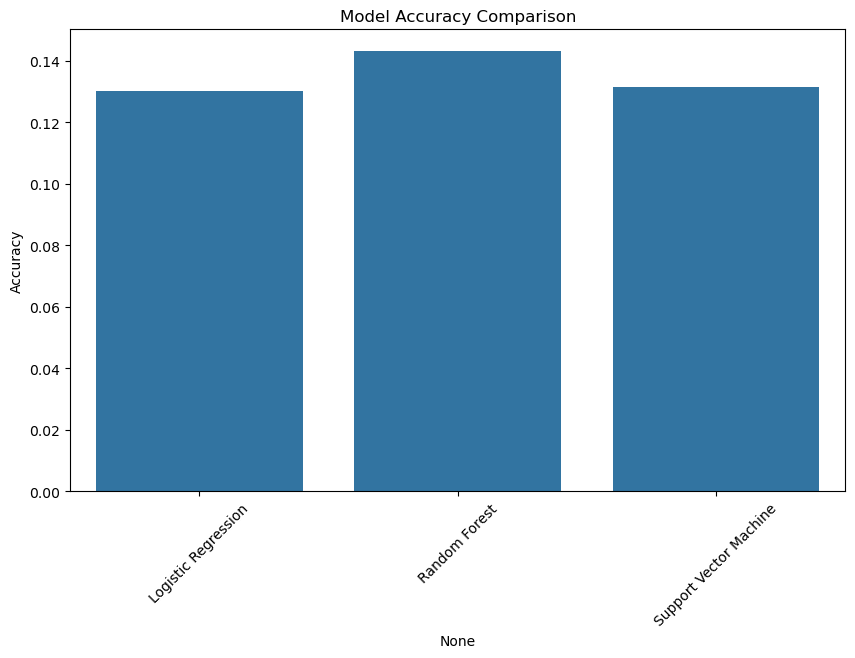

In [13]:
# Model Comparison
results_df = pd.DataFrame({name: {"Accuracy": res["Accuracy"]} for name, res in results.items()}).T
print("\nModel Comparison:")
print(results_df)

# barplot for model comparison
plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()
